# FMCG Sales & Marketing Analysis (2023–2025)

**Domain:** FMCG | Consumer Goods
**Tools:** Python, Pandas, Matplotlib
**Dataset:** 18,240 transactions across 3 years

## Objective
Analyze sales, marketing spend, and profitability patterns
to derive actionable business insights for FMCG companies.

## Key Findings
- 🏆 Europe = highest profit ($1.13M) and strong ROI (217%)
- 💡 South America = best marketing ROI (229%) — underinvested
- 📦 No Promo strategy outperforms all discount campaigns
- 🛒 Wholesale drives 36% of total revenue
- 🏠 Household & Personal Care = top 2 profitable categories

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/fmcg_sales_marketing_profitability_2023_2025.csv')

In [4]:
print("shape:",df.shape)
print("columns:",df.columns.to_list())
print("\nmissing_values:\n",df.isnull().sum())

shape: (18240, 27)
columns: ['Order_ID', 'Order_Date', 'Year', 'Quarter', 'Month', 'Month_Name', 'Region', 'Country', 'City', 'Sales_Person', 'Customer_Type', 'Sales_Channel', 'Promotion_Type', 'Product_Category', 'Brand', 'Product_Name', 'SKU', 'Units_Sold', 'Unit_Price_USD', 'Discount_Pct', 'Gross_Sales_USD', 'Marketing_Spend_USD', 'COGS_USD', 'Logistics_Cost_USD', 'Net_Revenue_USD', 'Profit_USD', 'Profit_Margin_Pct']

missing_values:
 Order_ID               0
Order_Date             0
Year                   0
Quarter                0
Month                  0
Month_Name             0
Region                 0
Country                0
City                   0
Sales_Person           0
Customer_Type          0
Sales_Channel          0
Promotion_Type         0
Product_Category       0
Brand                  0
Product_Name           0
SKU                    0
Units_Sold             0
Unit_Price_USD         0
Discount_Pct           0
Gross_Sales_USD        0
Marketing_Spend_USD    0
COGS_USD

## Data Overview
- 18,240 transactions | 27 columns | 2023–2025
- No missing values found — dataset is clean
- Key columns: Region, Product_Category, Brand,
  Sales_Channel, Promotion_Type, Marketing_Spend_USD, Profit_USD

## Q1: Which Region generates the highest Total Profit?

In [5]:
region_profit = df.groupby('Region')['Profit_USD'].sum().sort_values(ascending=False)
print(region_profit)

Region
Europe           1135420.40
North America     780169.10
Asia              670320.46
South America     404226.59
Oceania           318828.76
Name: Profit_USD, dtype: float64


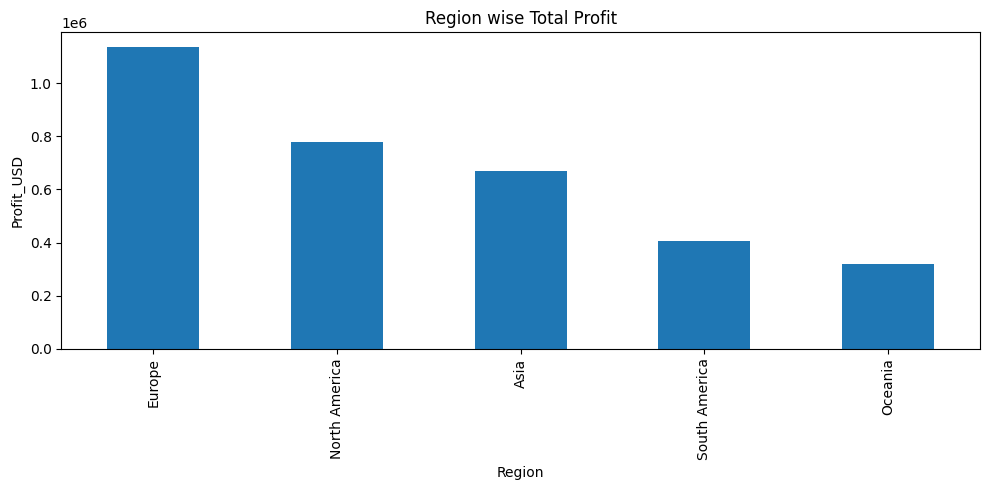

In [6]:
region_profit.plot(kind='bar',figsize=(10,5),title='Region wise Total Profit')
plt.xlabel('Region')
plt.ylabel('Profit_USD')
plt.tight_layout()
plt.show()

## Q2: Which are the Top 5 Best Selling Product Categories?

In [7]:
best_selling_products = df.groupby('Product_Category')['Units_Sold'].sum().sort_values(ascending=False)
print(best_selling_products)

Product_Category
Beverages            981268
Snacks               912058
Personal Care        686448
Household            683008
Dairy & Breakfast    620692
Name: Units_Sold, dtype: int64


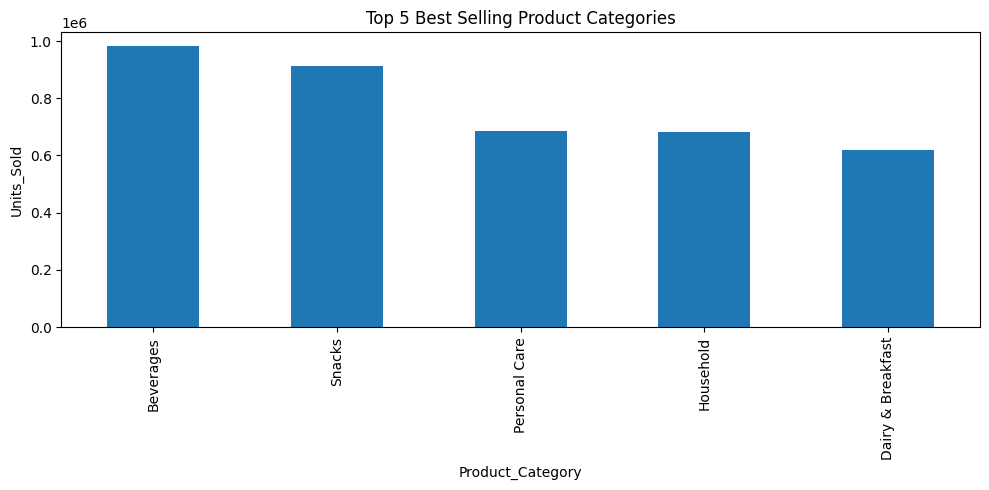

In [8]:
best_selling_products.plot(kind='bar',figsize=(10,5),title='Top 5 Best Selling Product Categories')
plt.xlabel('Product_Category')
plt.ylabel('Units_Sold')
plt.tight_layout()
plt.show()

## Q3: What is the relationship between Marketing Spend and Profit?

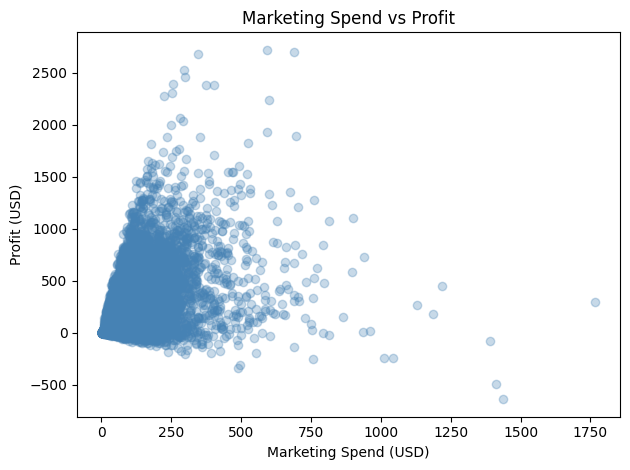

In [10]:
plt.scatter(df['Marketing_Spend_USD'], df['Profit_USD'], alpha=0.3, color='steelblue')
plt.title('Marketing Spend vs Profit')
plt.xlabel('Marketing Spend (USD)')
plt.ylabel('Profit (USD)')
plt.tight_layout()
plt.show()

### Insight:
Higher marketing spend does not guarantee higher profit.
Low-spend transactions show stronger profit margins,
suggesting marketing efficiency matters more than spend volume.

## Q4: What is the Year wise Revenue Trend?

In [11]:
revenue_trend = df[['Year','Net_Revenue_USD']].groupby('Year').sum().sort_values('Year',ascending=False).head()
print(revenue_trend)

      Net_Revenue_USD
Year                 
2025       5016279.43
2024       4840333.97
2023       4593306.60


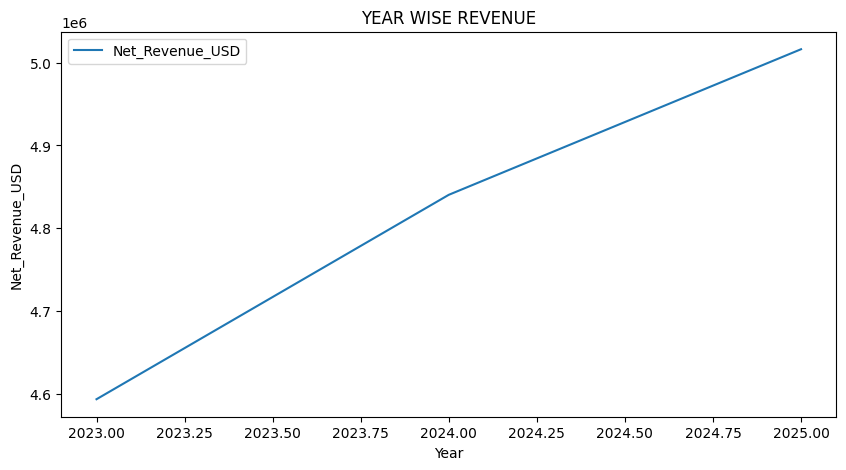

In [12]:
revenue_trend.plot(kind='line',figsize=(10,5),title='YEAR WISE REVENUE')
plt.xlabel('Year')
plt.ylabel('Net_Revenue_USD')
plt.show()

## Q5: Which Sales Channel performs better — Online or Offline?

In [13]:
Performance = df[['Sales_Channel','Net_Revenue_USD']].groupby('Sales_Channel').sum().sort_values('Net_Revenue_USD',ascending=False).head()
print(Performance)

               Net_Revenue_USD
Sales_Channel                 
Wholesale           5208657.92
Distributor         4451811.56
Modern Trade        3371020.34
Online              1418430.18


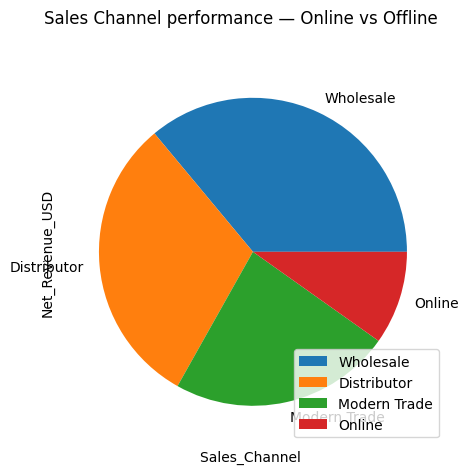

In [14]:
Performance.plot(kind='pie',figsize=(10,5),title='Sales Channel performance — Online vs Offline',subplots=True)
plt.xlabel('Sales_Channel ')
plt.ylabel('Net_Revenue_USD')
plt.show()

## Q6: Which Promotion Type generates the highest Profit?

In [15]:
promotion = df[['Promotion_Type','Profit_USD']].groupby('Promotion_Type').sum().sort_values('Profit_USD',ascending=False).head()
print(promotion)

                   Profit_USD
Promotion_Type               
No Promo           1432411.66
Bundle Offer        487231.45
Seasonal Campaign   477538.93
Flash Discount      306545.88
Loyalty Cashback    281314.87


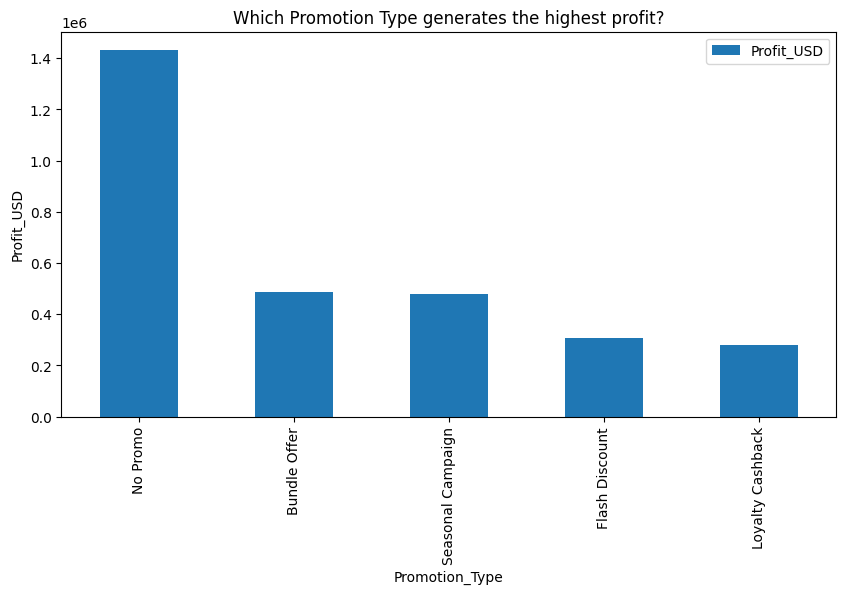

In [16]:
promotion.plot(kind='bar',figsize=(10,5),title='Which Promotion Type generates the highest profit?')
plt.xlabel('Promotion_Type')
plt.ylabel('Profit_USD')
plt.show()

## Q7: Which Brand has the highest Profit Margin?

In [27]:
brand_profit_margin = df[['Brand','Profit_Margin_Pct']].groupby('Brand').mean().sort_values('Profit_Margin_Pct',ascending=False).head(10)
print(brand_profit_margin)

             Profit_Margin_Pct
Brand                         
BrightSmile          30.677250
FarmJoy              27.716171
FreshNest            25.816638
SparkShield          24.805372
MorningCo            24.233631
HomeNest             22.637192
PantryPeak           21.730096
PureLiva             21.433242
Softora              20.966967
NutriBite            20.466882


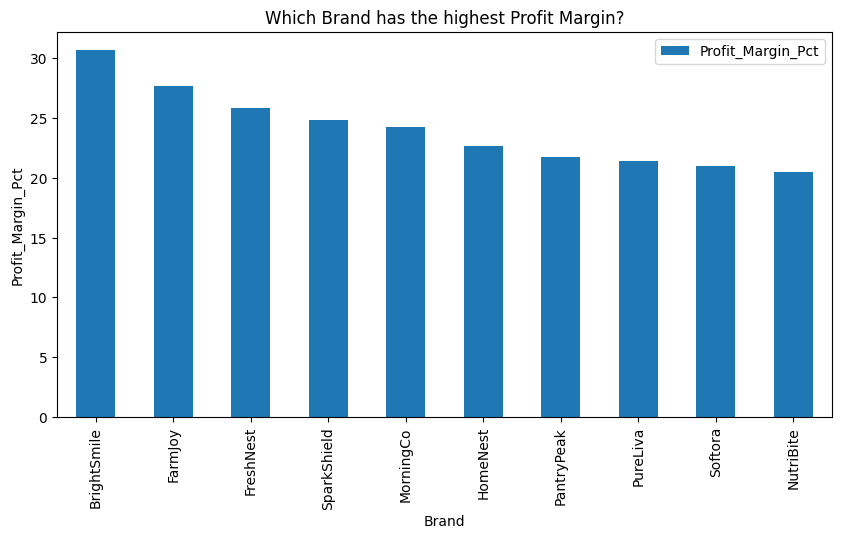

In [28]:
brand_profit_margin.plot(kind='bar',figsize=(10,5),title='Which Brand has the highest Profit Margin?')
plt.xlabel('Brand')
plt.ylabel('Profit_Margin_Pct')
plt.show()

## Q8: Which Region has the best Marketing ROI?

In [23]:
df['marketing_ROI'] = (df['Profit_USD'] / df['Marketing_Spend_USD']) *100

In [29]:
ROI = df.groupby('Region')['marketing_ROI'].mean().sort_values(ascending=False)
print(ROI)

Region
South America    229.425085
Europe           217.702579
North America    215.946853
Asia             215.746979
Oceania          185.433228
Name: marketing_ROI, dtype: float64


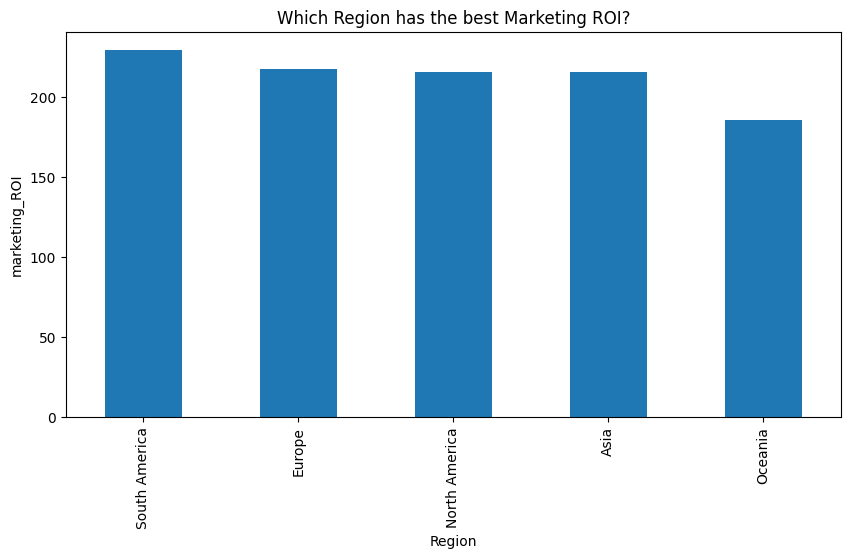

In [30]:
ROI.plot(kind='bar',figsize=(10,5),title='Which Region has the best Marketing ROI?')
plt.xlabel('Region')
plt.ylabel('marketing_ROI')
plt.show()

## Q9: Which Product Category is most Profitable?

In [21]:
category = df.groupby('Product_Category')['Profit_USD'].sum().sort_values(ascending=False).head(10)
print(category)

Product_Category
Household            832221.58
Personal Care        776980.16
Dairy & Breakfast    620349.83
Snacks               555212.09
Beverages            524201.65
Name: Profit_USD, dtype: float64


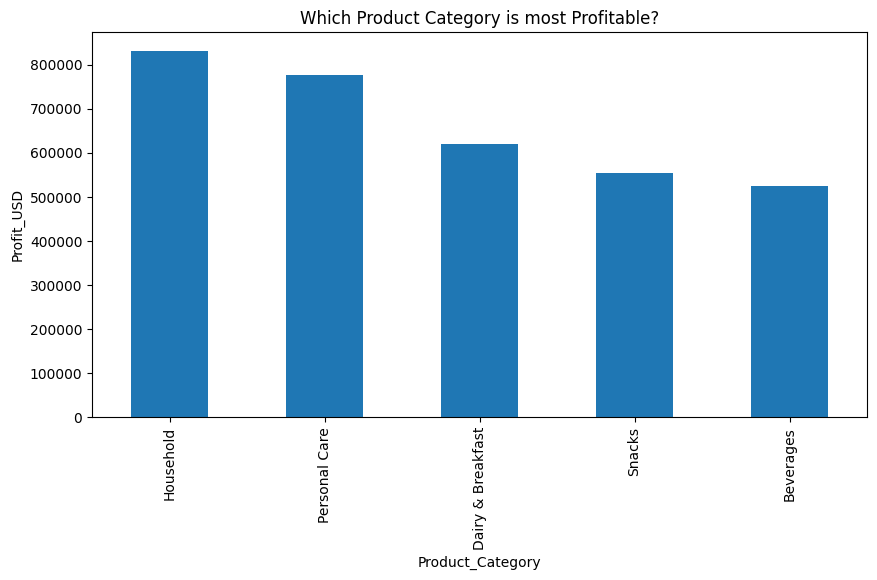

In [22]:
category.plot(kind='bar',figsize=(10,5),title='Which Product Category is most Profitable?')
plt.xlabel('Product_Category')
plt.ylabel('Profit_USD')
plt.show()

## Q10: Business Recommendations

In [31]:
print("Region wise profit:\n", df.groupby('Region')['Profit_USD'].sum().sort_values(ascending=False))
print("\nTop Promotion:\n", df.groupby('Promotion_Type')['Profit_USD'].sum().sort_values(ascending=False).head(3))
print("\nTop Category:\n", df.groupby('Product_Category')['Profit_USD'].sum().sort_values(ascending=False).head(3))
print("\nBest ROI Region:\n", df.groupby('Region')['marketing_ROI'].mean().sort_values(ascending=False).head(3))
print("\nSales Channel:\n", df.groupby('Sales_Channel')['Net_Revenue_USD'].sum())

Region wise profit:
 Region
Europe           1135420.40
North America     780169.10
Asia              670320.46
South America     404226.59
Oceania           318828.76
Name: Profit_USD, dtype: float64

Top Promotion:
 Promotion_Type
No Promo             1432411.66
Bundle Offer          487231.45
Seasonal Campaign     477538.93
Name: Profit_USD, dtype: float64

Top Category:
 Product_Category
Household            832221.58
Personal Care        776980.16
Dairy & Breakfast    620349.83
Name: Profit_USD, dtype: float64

Best ROI Region:
 Region
South America    229.425085
Europe           217.702579
North America    215.946853
Name: marketing_ROI, dtype: float64

Sales Channel:
 Sales_Channel
Distributor     4451811.56
Modern Trade    3371020.34
Online          1418430.18
Wholesale       5208657.92
Name: Net_Revenue_USD, dtype: float64


Based on analysis of 18,240 FMCG transactions (2023–2025):

**1. Double down on Europe**
Europe leads with $1.13M total profit and 217% marketing ROI.
Increasing marketing budget allocation here will yield the
highest returns compared to other regions.

**2. South America is a hidden gem**
Highest marketing ROI at 229% despite ranking 4th in total profit.
Low spend, high efficiency — increasing investment here could
significantly boost overall profitability.

**3. No Promo strategy outperforms discounts**
"No Promo" transactions generated $1.43M profit — 3x more than
Bundle Offers or Seasonal Campaigns. Heavy discounting is hurting
margins. Reduce promotional spend on low-ROI campaigns.

**4. Focus on Household & Personal Care categories**
Top 2 most profitable categories. Sales and marketing efforts
should prioritize these over lower-margin categories.

**5. Wholesale & Distributor dominate revenue**
Online channel contributes only 21% of revenue despite
growing digital trends. Investing in online channel
infrastructure could unlock significant untapped revenue.